<a href="https://colab.research.google.com/github/mpatel5/CSCI_221_Final_Project/blob/main/Final_Part1_Multilinear_Regression_R.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part 1: Multi-Linear Regression in R
* Dataset: developer_burnout.csv
* Target Variable: burnout_level

In [ ]:
# Install packages if needed
# install.packages("readr")
# install.packages("dplyr")
# install.packages("ggplot2")
install.packages("Metrics")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



# Import Libraries

In [ ]:
library(readr)
library(dplyr)
library(ggplot2)
library(Metrics)

# Load dataset

In [ ]:
df <- read_csv("developer_burnout.csv")

Rows: 7000 Columns: 12
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (1): burnout_level
dbl (11): age, experience_years, daily_work_hours, sleep_hours, caffeine_int...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


# Preview the data

In [ ]:
cat("First 5 rows:\n")
print(head(df))

cat("\nDataset structure:\n")
str(df)

cat("\nSummary statistics:\n")
print(summary(df))

cat("\nColumn names:\n")
print(colnames(df))

First 5 rows:
# A tibble: 6 × 12
    age experience_years daily_work_hours sleep_hours caffeine_intake
  <dbl>            <dbl>            <dbl>       <dbl>           <dbl>
1    26               12            10.3         4.45               2
2    39               10             8.62        5.77               5
3    34               13            NA           4.03               5
4    30                1             6.85        6.47               2
5    27                7             4.24        5.8               NA
6    40                2            10.2         6.78               0
# ℹ 7 more variables: bugs_per_day <dbl>, commits_per_day <dbl>,
#   meetings_per_day <dbl>, screen_time <dbl>, exercise_hours <dbl>,
#   stress_level <dbl>, burnout_level <chr>

Dataset structure:
spc_tbl_ [7,000 × 12] (S3: spec_tbl_df/tbl_df/tbl/data.frame)
 $ age             : num [1:7000] 26 39 34 30 27 40 26 38 42 30 ...
 $ experience_years: num [1:7000] 12 10 13 1 7 2 NA 0 18 17 ...
 $ daily_work_h

# Visualization of the data

Warning message:
“Removed 140 rows containing non-finite outside the scale range (`stat_bin()`).”
Warning message:
“Removed 140 rows containing non-finite outside the scale range (`stat_bin()`).”


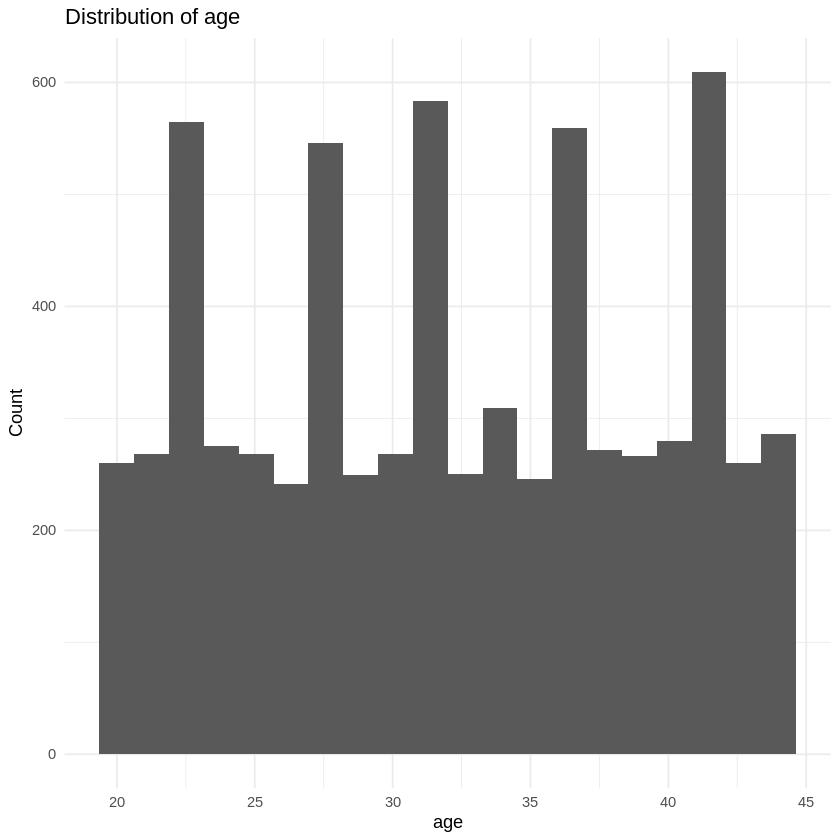

Warning message:
“Removed 140 rows containing non-finite outside the scale range (`stat_bin()`).”


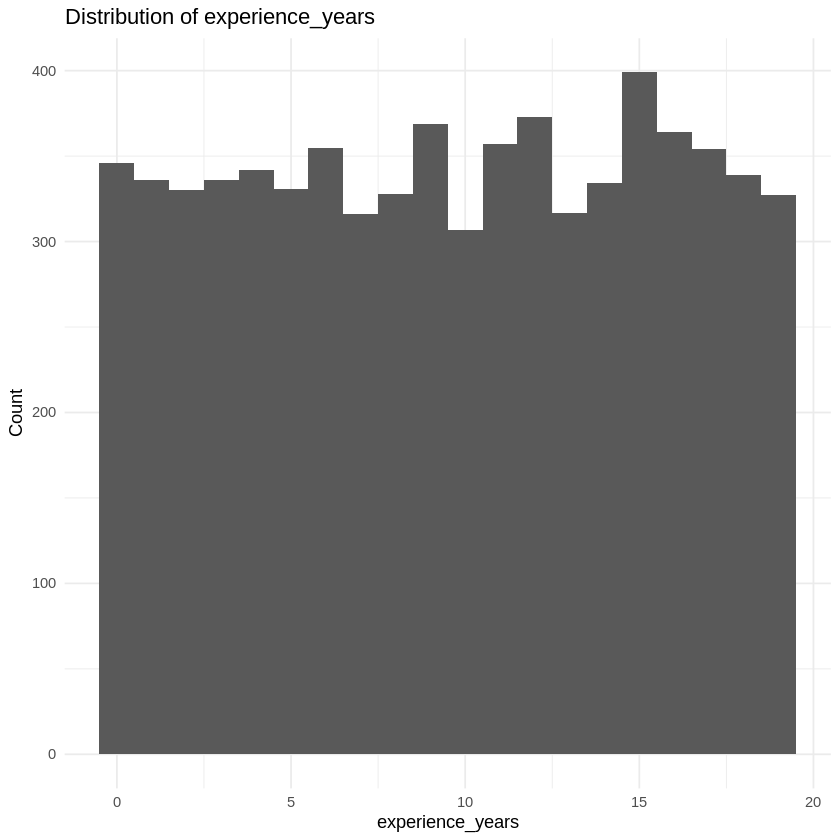

Warning message:
“Removed 140 rows containing non-finite outside the scale range (`stat_bin()`).”


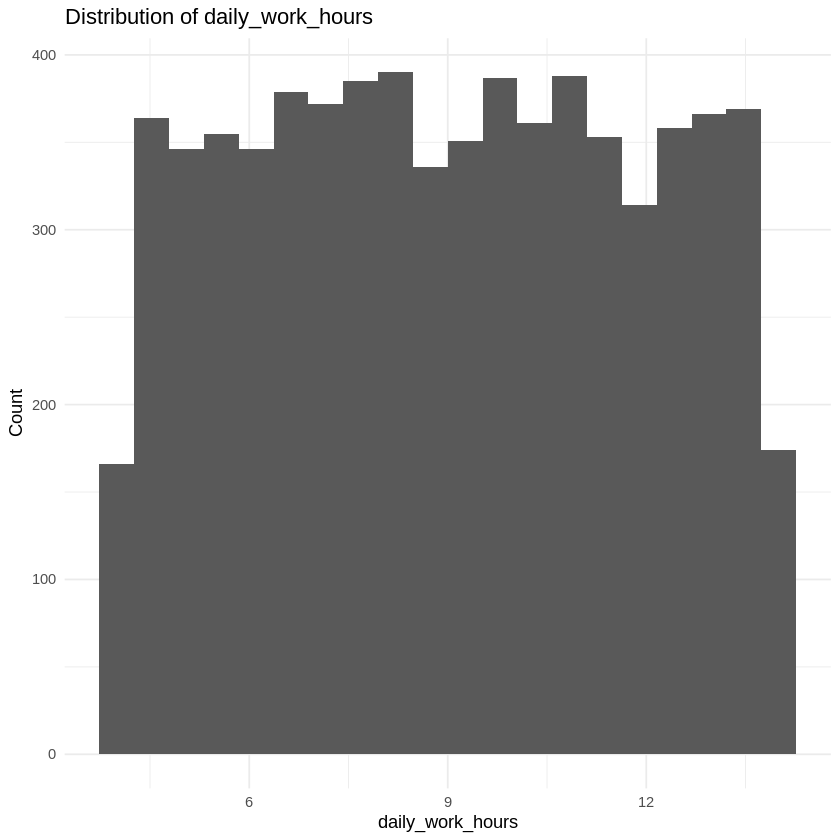

Warning message:
“Removed 140 rows containing non-finite outside the scale range (`stat_bin()`).”


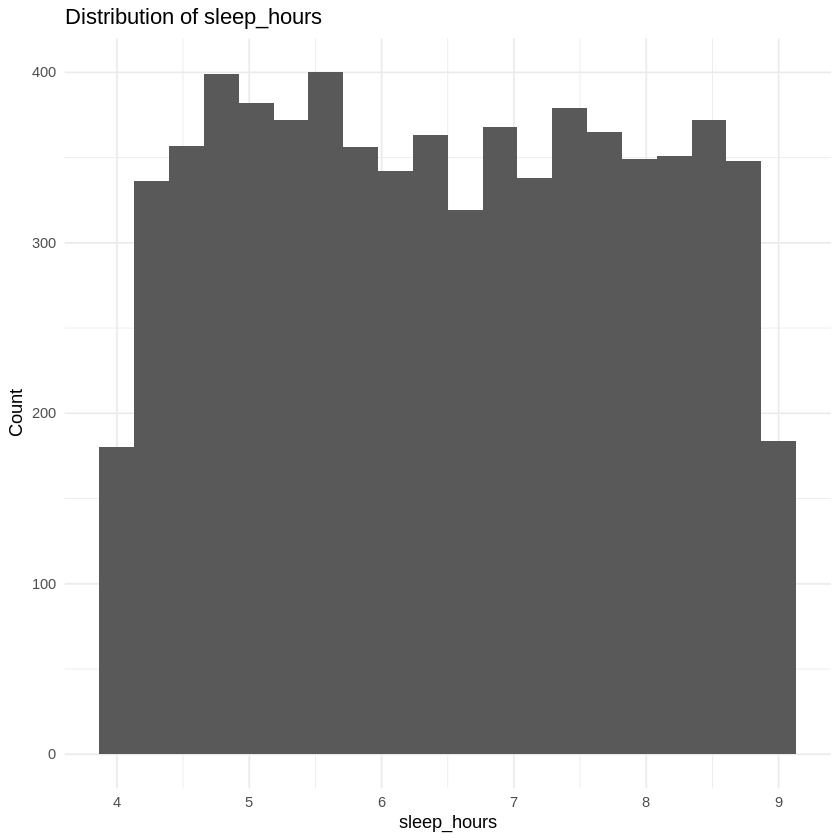

Warning message:
“Removed 140 rows containing non-finite outside the scale range (`stat_bin()`).”


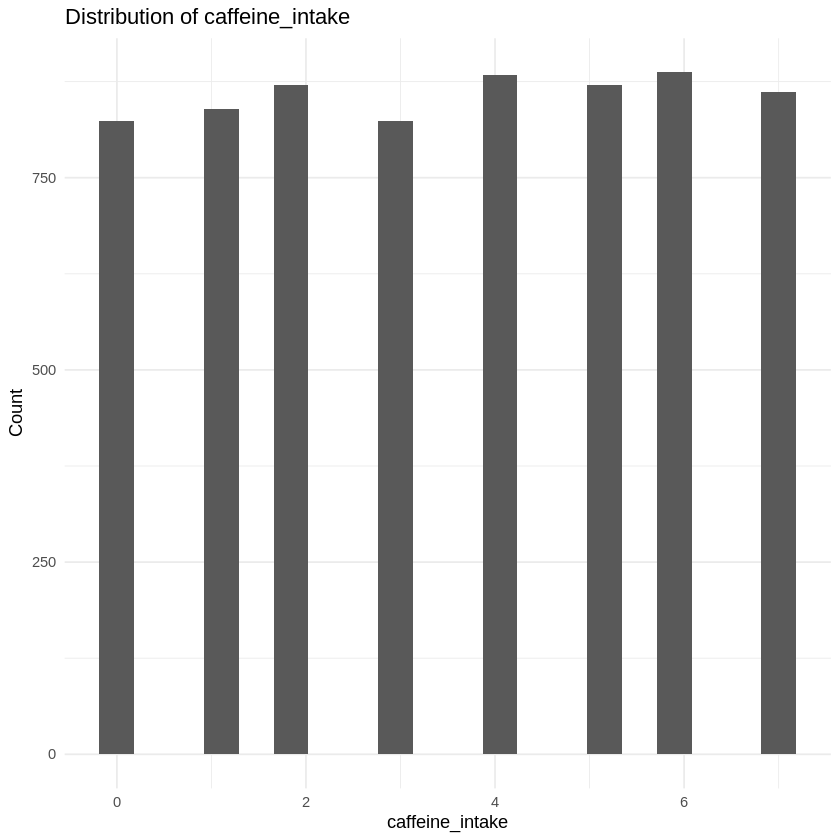

Warning message:
“Removed 140 rows containing non-finite outside the scale range (`stat_bin()`).”


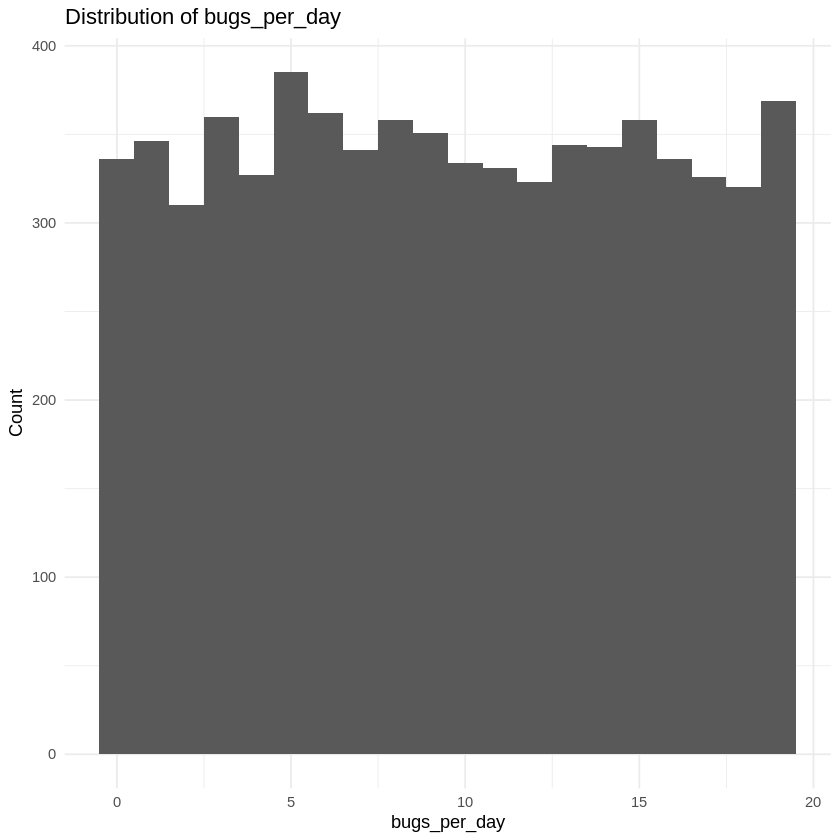

Warning message:
“Removed 140 rows containing non-finite outside the scale range (`stat_bin()`).”


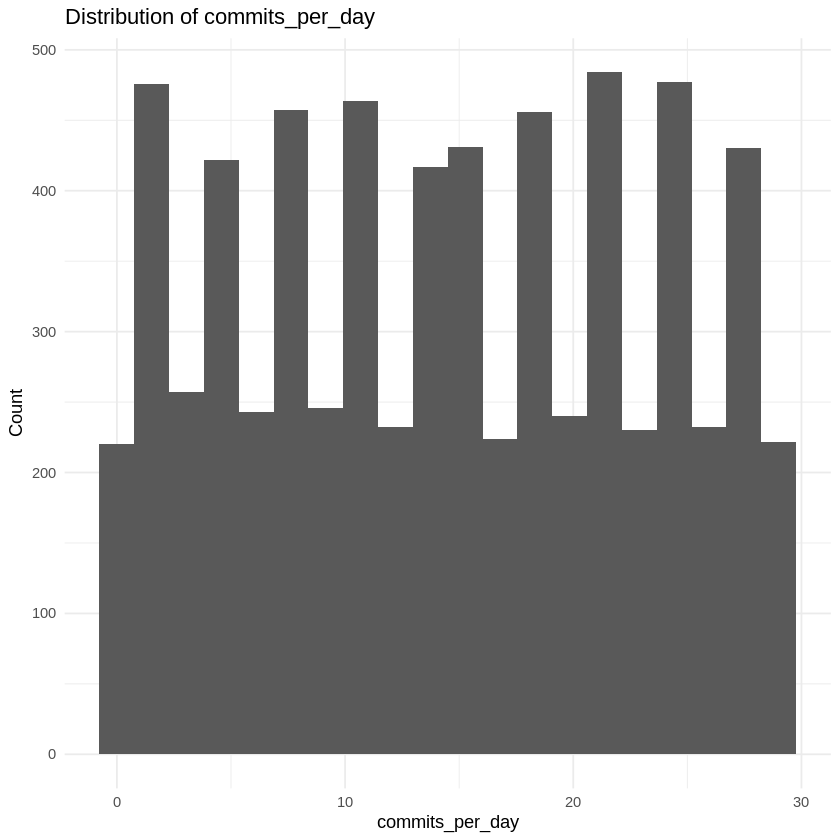

Warning message:
“Removed 140 rows containing non-finite outside the scale range (`stat_bin()`).”


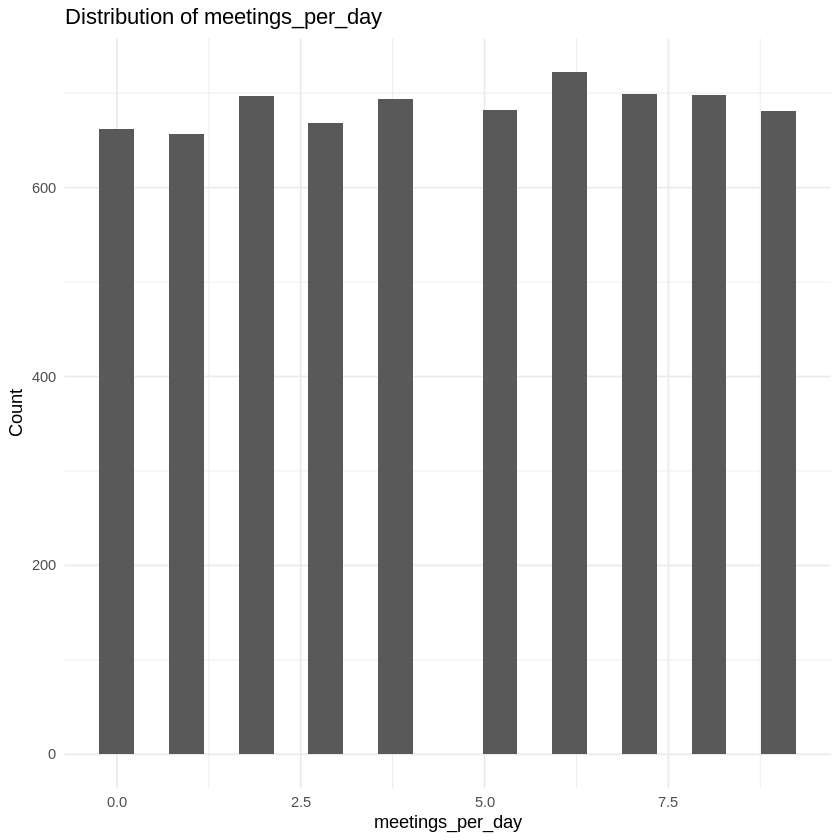

Warning message:
“Removed 140 rows containing non-finite outside the scale range (`stat_bin()`).”


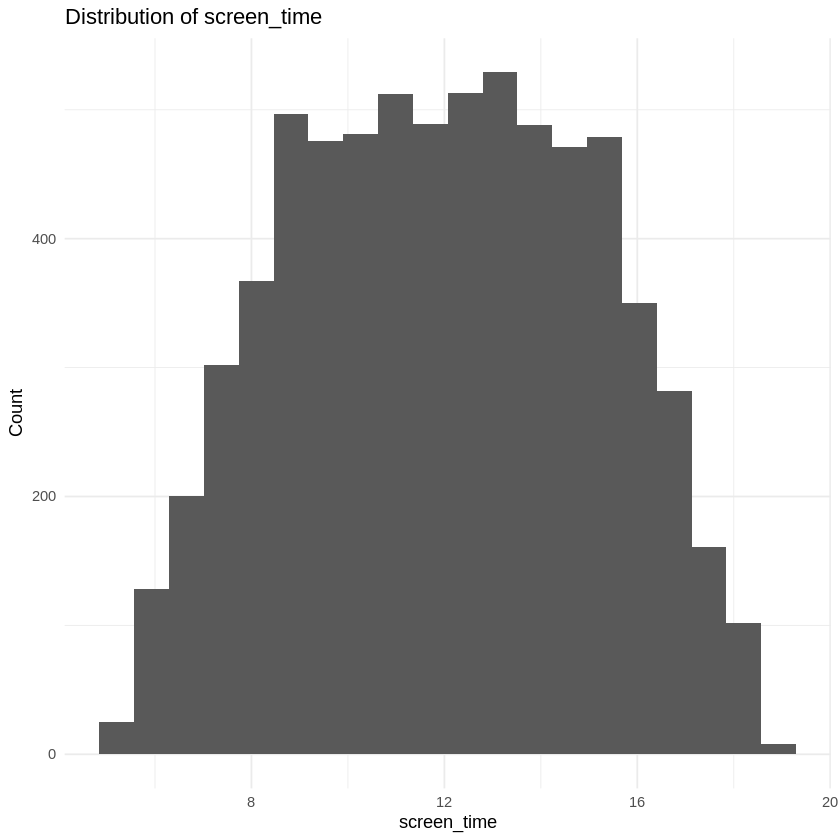

Warning message:
“Removed 140 rows containing non-finite outside the scale range (`stat_bin()`).”


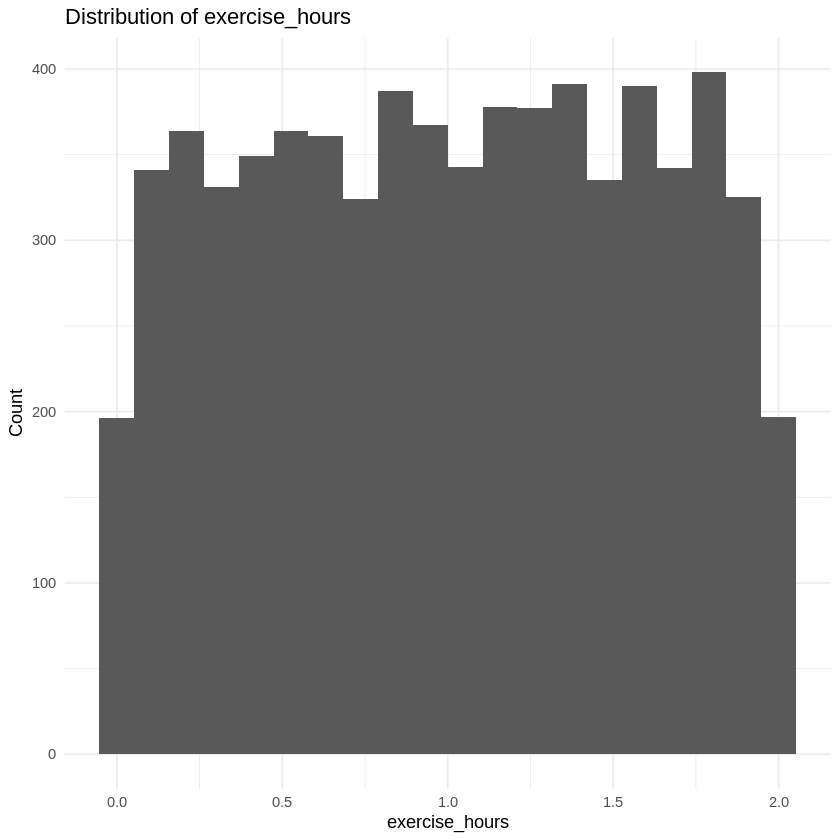

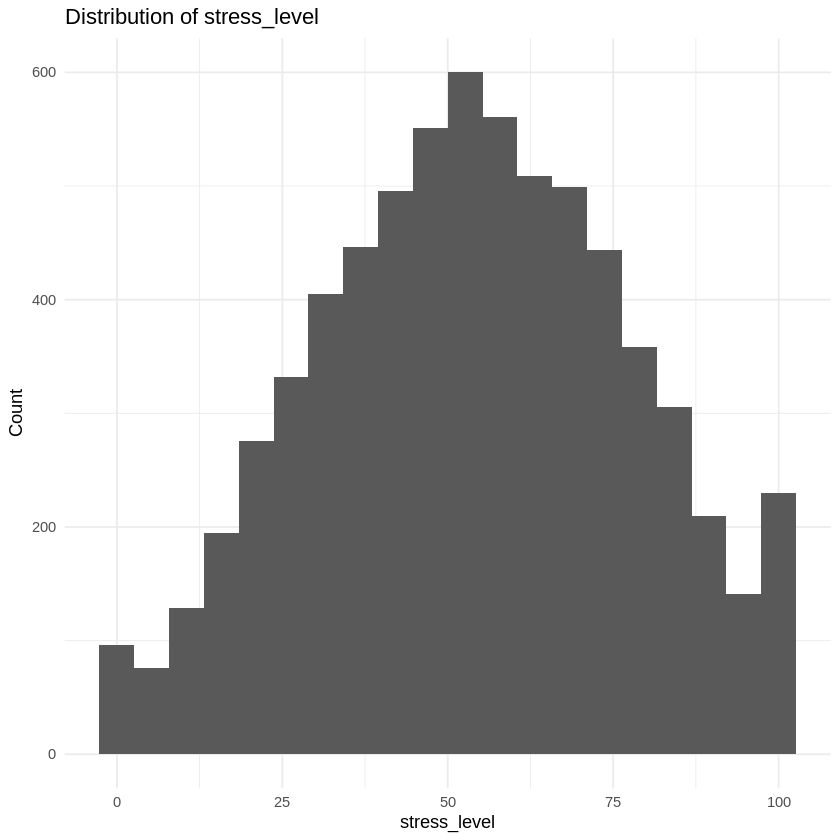

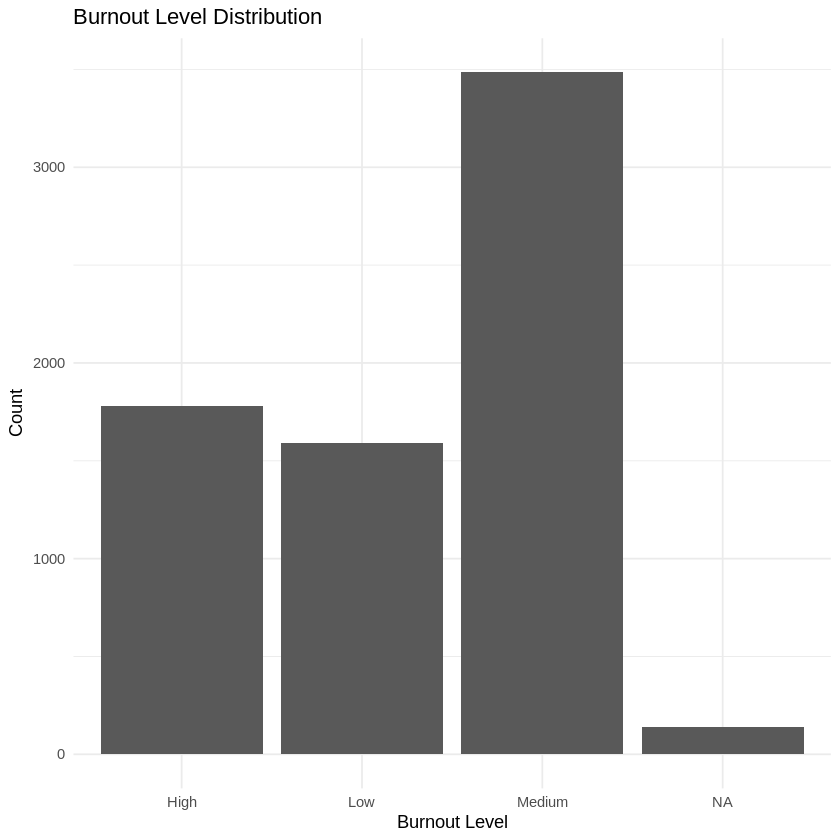

In [ ]:
numeric_cols <- df %>% select(where(is.numeric))

# Histograms for numeric variables
for (col in names(numeric_cols)) {
  print(
    ggplot(df, aes(x = .data[[col]])) +
      geom_histogram(bins = 20) +
      labs(
        title = paste("Distribution of", col),
        x = col,
        y = "Count"
      ) +
      theme_minimal()
  )
}

# Bar chart for target variable
print(
  ggplot(df, aes(x = burnout_level)) +
    geom_bar() +
    labs(
      title = "Burnout Level Distribution",
      x = "Burnout Level",
      y = "Count"
    ) +
    theme_minimal()
)

# Check for duplicates

In [ ]:
duplicate_count <- sum(duplicated(df))
cat("\nDuplicate rows:", duplicate_count, "\n")

if (duplicate_count == 0) {
  cat("No duplicate rows found, so no removal was necessary.\n")
} else {
  df <- df[!duplicated(df), ]
  cat("Duplicate rows were removed.\n")
}


Duplicate rows: 0 
No duplicate rows found, so no removal was necessary.


# Check for missing values and impute missing values

* I used median imputation for missing numeric values because the median is less affected by extreme values or skewed data than the mean. Since variables like work hours, screen time, stress level, sleep, and exercise may not be perfectly normally distributed, the median gives a more stable replacement value.

* Rows with missing burnout_level were removed because burnout_level is the target variable. Imputing the outcome could artificially create labels and bias the regression model.

In [ ]:
cat("\nMissing values before cleaning:\n")
print(colSums(is.na(df)))

# Median imputation is used for numeric predictors because the median
# is less affected by skewed data and extreme values than the mean.

df <- df %>%
  mutate(across(where(is.numeric), ~ ifelse(is.na(.), median(., na.rm = TRUE), .)))

# Rows with missing burnout_level are removed because burnout_level is
# the target variable. Imputing the target would create artificial outcomes.

df <- df %>%
  filter(!is.na(burnout_level))

cat("\nMissing values after cleaning:\n")
print(colSums(is.na(df)))


Missing values before cleaning:
             age experience_years daily_work_hours      sleep_hours 
             140              140              140              140 
 caffeine_intake     bugs_per_day  commits_per_day meetings_per_day 
             140              140              140              140 
     screen_time   exercise_hours     stress_level    burnout_level 
             140              140              140              140 

Missing values after cleaning:
             age experience_years daily_work_hours      sleep_hours 
               0                0                0                0 
 caffeine_intake     bugs_per_day  commits_per_day meetings_per_day 
               0                0                0                0 
     screen_time   exercise_hours     stress_level    burnout_level 
               0                0                0                0 


# Check outliers


--- IQR Outlier Detection ---
age : 0 outliers
experience_years : 0 outliers
daily_work_hours : 0 outliers
sleep_hours : 0 outliers
caffeine_intake : 0 outliers
bugs_per_day : 0 outliers
commits_per_day : 0 outliers
meetings_per_day : 0 outliers
screen_time : 0 outliers
exercise_hours : 0 outliers
stress_level : 0 outliers

--- Z-Score Outlier Detection ---
age : 0 outliers
experience_years : 0 outliers
daily_work_hours : 0 outliers
sleep_hours : 0 outliers
caffeine_intake : 0 outliers
bugs_per_day : 0 outliers
commits_per_day : 0 outliers
meetings_per_day : 0 outliers
screen_time : 0 outliers
exercise_hours : 0 outliers
stress_level : 0 outliers

--- Outlier Comparison Summary ---
age → IQR: 0 | Z-score: 0 
experience_years → IQR: 0 | Z-score: 0 
daily_work_hours → IQR: 0 | Z-score: 0 
sleep_hours → IQR: 0 | Z-score: 0 
caffeine_intake → IQR: 0 | Z-score: 0 
bugs_per_day → IQR: 0 | Z-score: 0 
commits_per_day → IQR: 0 | Z-score: 0 
meetings_per_day → IQR: 0 | Z-score: 0 
screen_time 

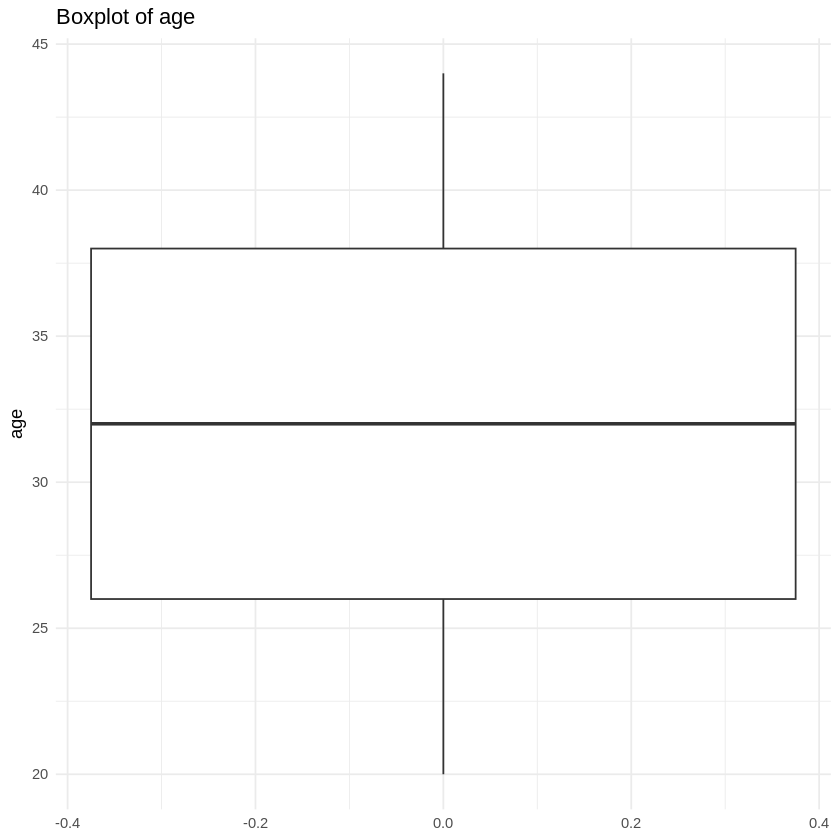

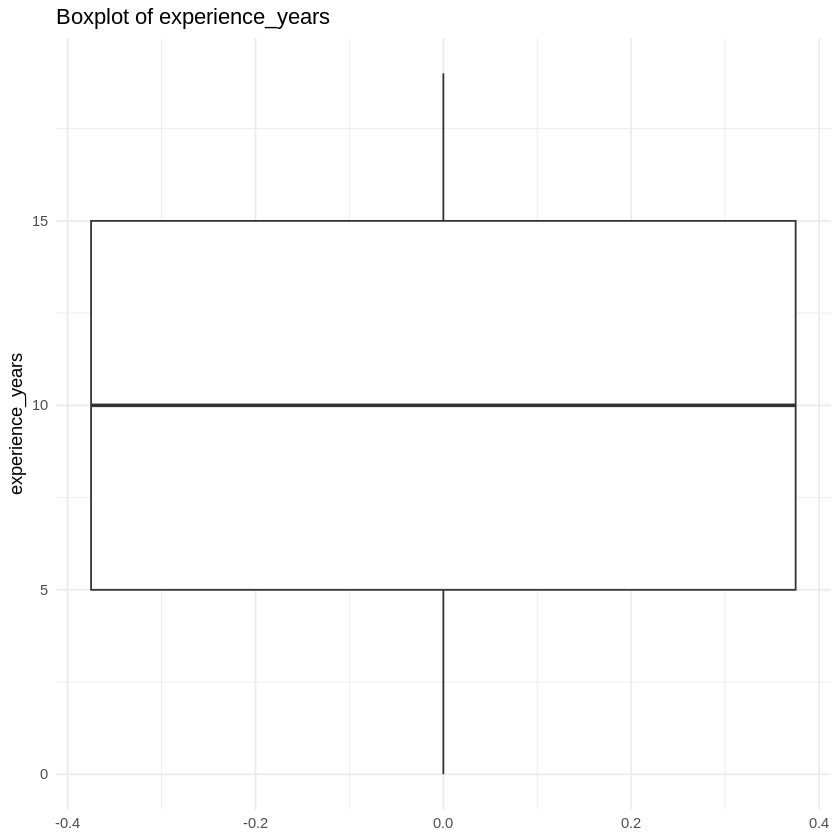

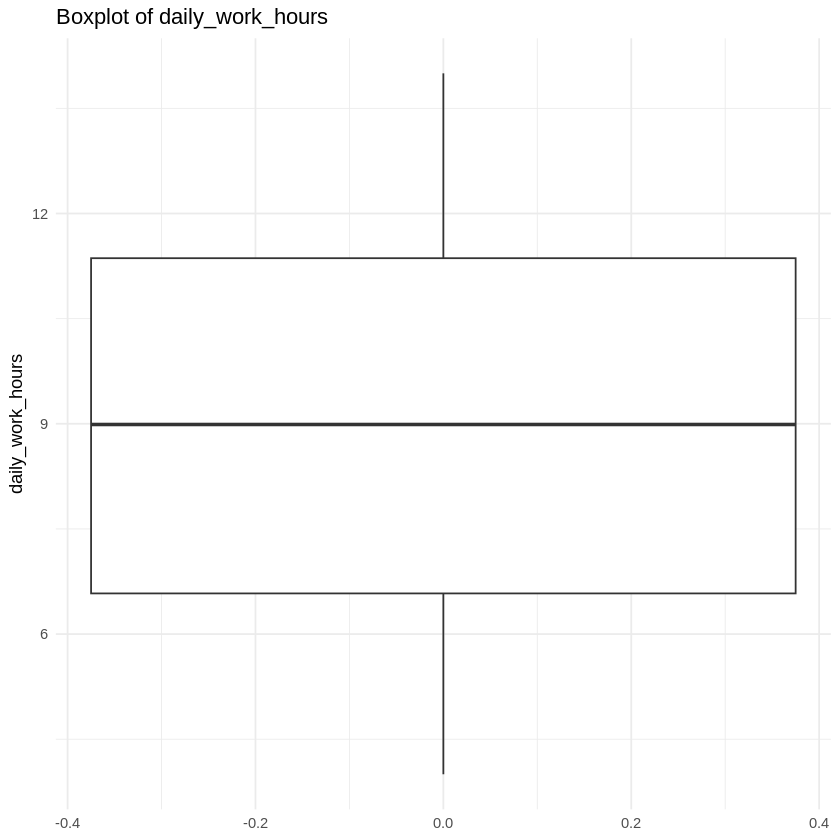

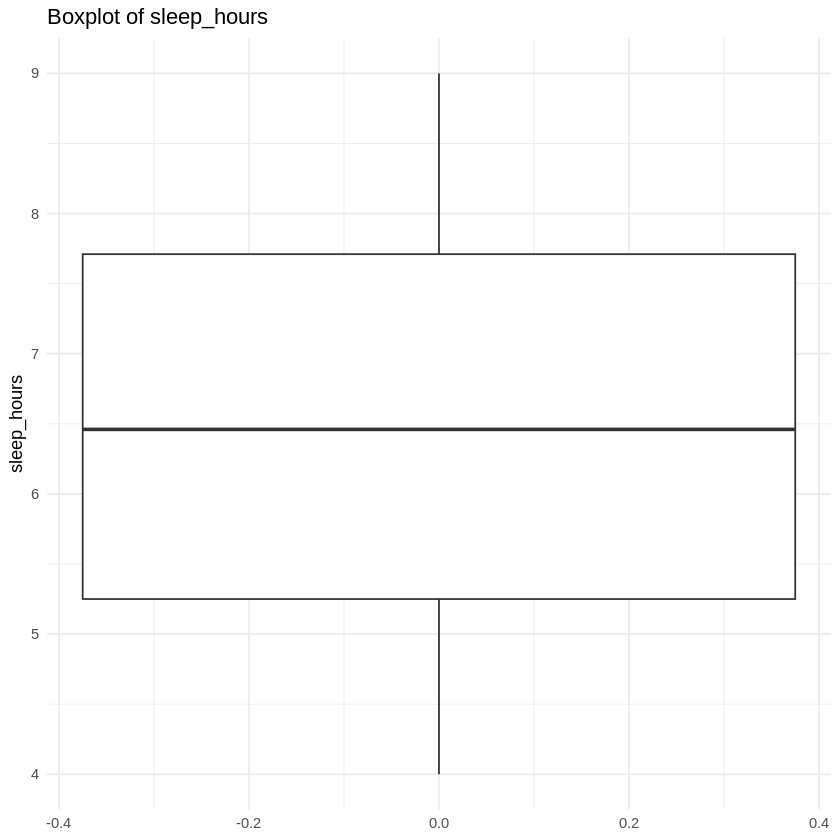

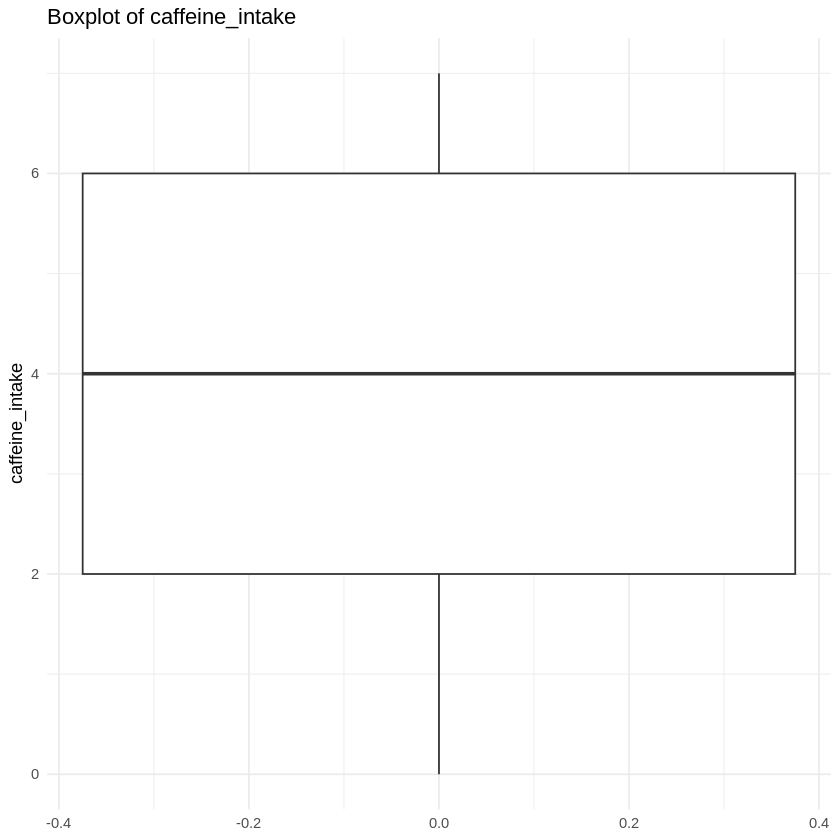

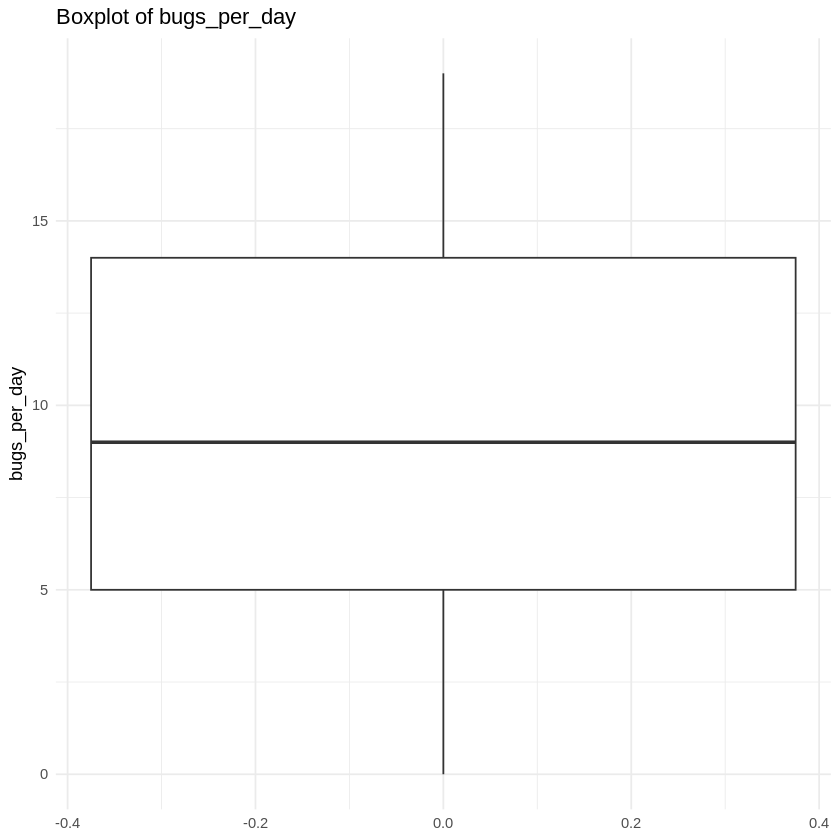

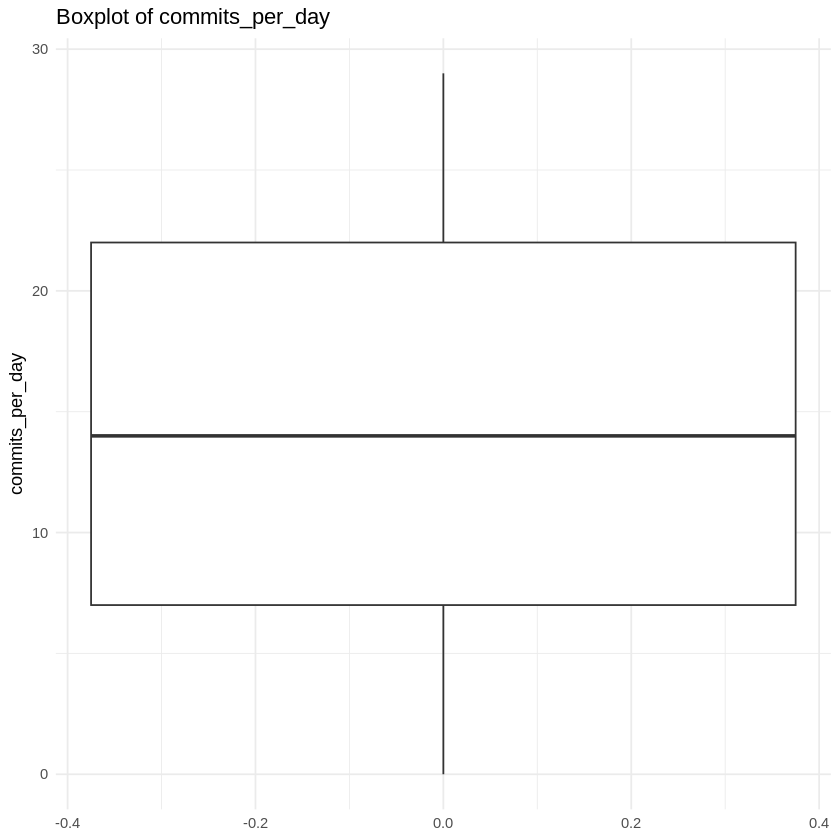

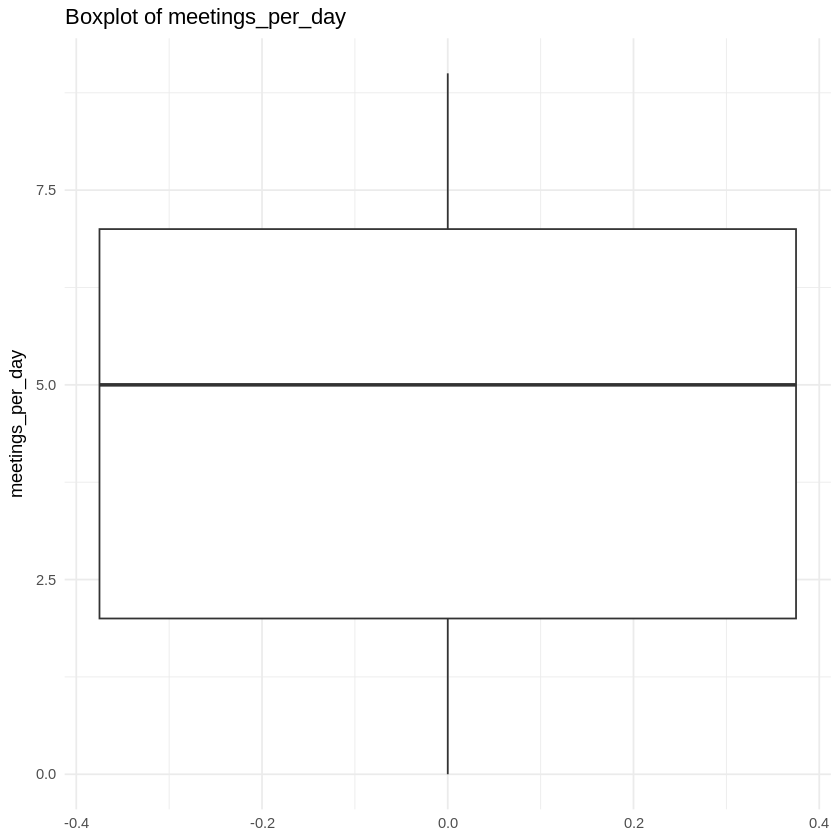

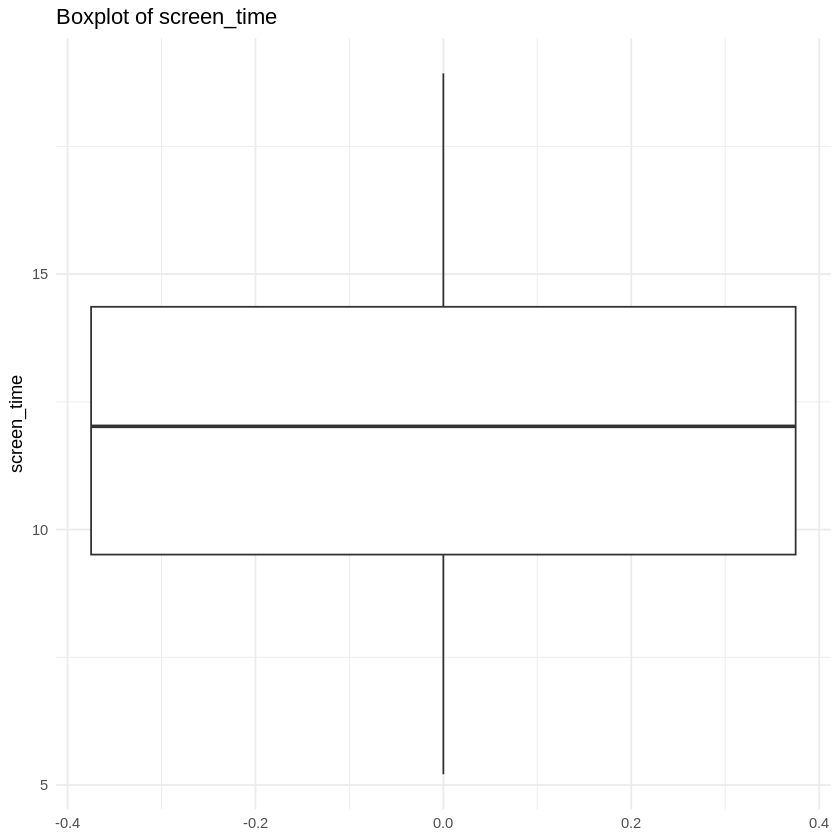

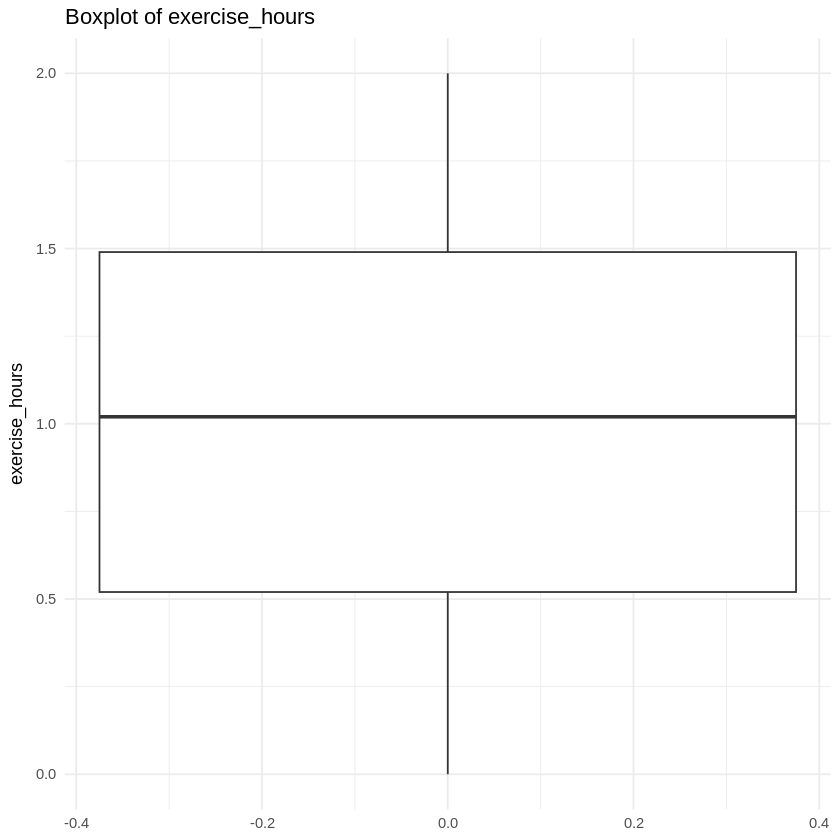

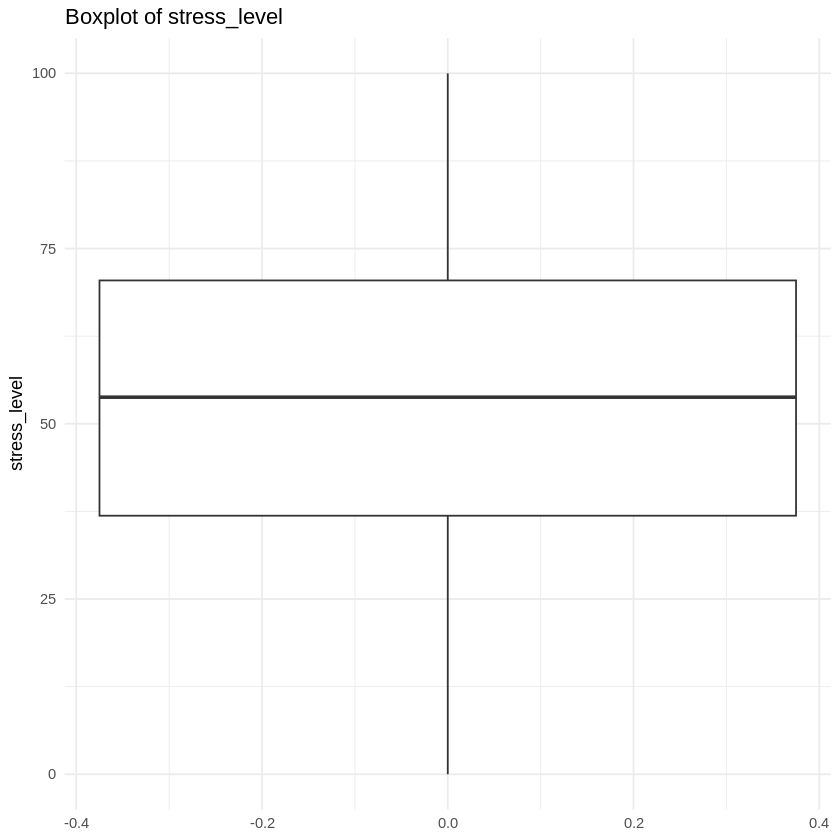

In [ ]:
# Outlier Detection: IQR Method

numeric_cols <- names(df %>% select(where(is.numeric)))

cat("\n--- IQR Outlier Detection ---\n")

iqr_outliers <- c()

for (col in numeric_cols) {
  q1 <- quantile(df[[col]], 0.25, na.rm = TRUE)
  q3 <- quantile(df[[col]], 0.75, na.rm = TRUE)
  iqr <- q3 - q1

  lower_bound <- q1 - 1.5 * iqr
  upper_bound <- q3 + 1.5 * iqr

  count <- sum(df[[col]] < lower_bound | df[[col]] > upper_bound, na.rm = TRUE)
  iqr_outliers[col] <- count

  cat(col, ":", count, "outliers\n")
}

# Outlier Detection: Z-Score Method

cat("\n--- Z-Score Outlier Detection ---\n")

z_outliers <- c()

for (col in numeric_cols) {
  z_values <- abs(scale(df[[col]]))
  count <- sum(z_values > 3, na.rm = TRUE)
  z_outliers[col] <- count

  cat(col, ":", count, "outliers\n")
}

# Outlier Comparison Summary

cat("\n--- Outlier Comparison Summary ---\n")

for (col in numeric_cols) {
  cat(col, "→ IQR:", iqr_outliers[col], "| Z-score:", z_outliers[col], "\n")
}

# Boxplots for visual confirmation

for (col in numeric_cols) {
  print(
    ggplot(df, aes(y = .data[[col]])) +
      geom_boxplot() +
      labs(
        title = paste("Boxplot of", col),
        y = col
      ) +
      theme_minimal()
  )
}

# Outliers were analyzed using both the IQR method and Z-score method.
* The IQR method identifies outliers using quartiles, while the Z-score method identifies values more than 3 standard deviations from the mean.
* Both methods produced similar results, and no significant outliers were detected.

# Convert target variable

* The target variable was encoded numerically to allow regression modeling while preserving the ordinal relationship between burnout levels.

In [ ]:
df <- df %>%
  mutate(
    burnout_level = case_when(
      burnout_level == "Low" ~ 1,
      burnout_level == "Medium" ~ 2,
      burnout_level == "High" ~ 3
    )
  )

cat("\nBurnout level after numeric conversion:\n")
print(table(df$burnout_level))


Burnout level after numeric conversion:

   1    2    3 
1593 3485 1782 


# Select predictors and target

* The predictor variables were selected because they are reasonably connected to burnout. Daily work hours and stress level represent work-related pressure, while sleep hours, exercise hours, and screen time represent lifestyle and recovery factors. Using several predictors helps the model explain burnout from both job-related and personal factors.

In [ ]:
model <- lm(
  burnout_level ~ daily_work_hours + sleep_hours + stress_level +
    screen_time + exercise_hours,
  data = df
)

# Train-test split

In [ ]:
set.seed(42)

train_index <- sample(1:nrow(df), 0.8 * nrow(df))

train_data <- df[train_index, ]
test_data <- df[-train_index, ]

model <- lm(
  burnout_level ~ daily_work_hours + sleep_hours + stress_level +
    screen_time + exercise_hours,
  data = train_data
)

predictions <- predict(model, test_data)

actual <- test_data$burnout_level

# Model summary with coefficients and p-values
cat("\nRegression Summary:\n")
print(summary(model))


Regression Summary:

Call:
lm(formula = burnout_level ~ daily_work_hours + sleep_hours + 
    stress_level + screen_time + exercise_hours, data = train_data)

Residuals:
     Min       1Q   Median       3Q      Max 
-1.03302 -0.24959 -0.00733  0.24404  0.97127 

Coefficients:
                   Estimate Std. Error t value Pr(>|t|)    
(Intercept)       0.5462408  0.0273555  19.968   <2e-16 ***
daily_work_hours  0.0030328  0.0035402   0.857    0.392    
sleep_hours      -0.0003377  0.0029651  -0.114    0.909    
stress_level      0.0270364  0.0002252 120.043   <2e-16 ***
screen_time       0.0007703  0.0031354   0.246    0.806    
exercise_hours   -0.0052472  0.0071129  -0.738    0.461    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.2984 on 5482 degrees of freedom
Multiple R-squared:  0.8203,	Adjusted R-squared:  0.8201 
F-statistic:  5004 on 5 and 5482 DF,  p-value: < 2.2e-16



# Evaluate model

In [ ]:
r2_train <- summary(model)$r.squared
adjusted_r2 <- summary(model)$adj.r.squared
rmse_value <- rmse(actual, predictions)

ss_total <- sum((actual - mean(actual))^2)
ss_res <- sum((actual - predictions)^2)
r2_test <- 1 - (ss_res / ss_total)

cat("\nModel Performance:\n")
cat("Training R²:", r2_train, "\n")
cat("Adjusted R²:", adjusted_r2, "\n")
cat("Test R²:", r2_test, "\n")
cat("RMSE:", rmse_value, "\n")
cat("Model Accuracy (%):", accuracy_percentage, "\n")


Model Performance:
Training R²: 0.8202679 
Adjusted R²: 0.820104 
Test R²: 0.8075576 
RMSE: 0.302568 
Model Accuracy (%): 80.75576 


# Coefficients

# Coefficient interpretation:
* Each coefficient shows how much the predicted burnout_level changes when that predictor increases by 1 unit, assuming all other predictors stay constant.

* A positive coefficient means the predictor is associated with higher burnout.
* A negative coefficient means the predictor is associated with lower burnout.

* For example, if stress_level has a positive coefficient, then higher stress is associated with higher predicted burnout. If sleep_hours has a negative coefficient, then more sleep is associated with lower predicted burnout.



In [ ]:
cat("\nRegression Coefficients:\n")
print(coef(model))


Regression Coefficients:
     (Intercept) daily_work_hours      sleep_hours     stress_level 
    0.5462408043     0.0030328018    -0.0003377311     0.0270363631 
     screen_time   exercise_hours 
    0.0007702902    -0.0052472460 


# Regression equation

In [ ]:
coefficients <- coef(model)

equation <- paste0("burnout_level = ", round(coefficients[1], 4))

for (i in 2:length(coefficients)) {
  equation <- paste0(
    equation,
    " + (",
    round(coefficients[i], 4),
    " * ",
    names(coefficients[i]),
    ")"
  )
}

cat("\nRegression Equation:\n")
cat(equation, "\n")


Regression Equation:
burnout_level = 0.5462 + (0.003 * daily_work_hours) + (-3e-04 * sleep_hours) + (0.027 * stress_level) + (8e-04 * screen_time) + (-0.0052 * exercise_hours) 


# Actual vs predicted visualization

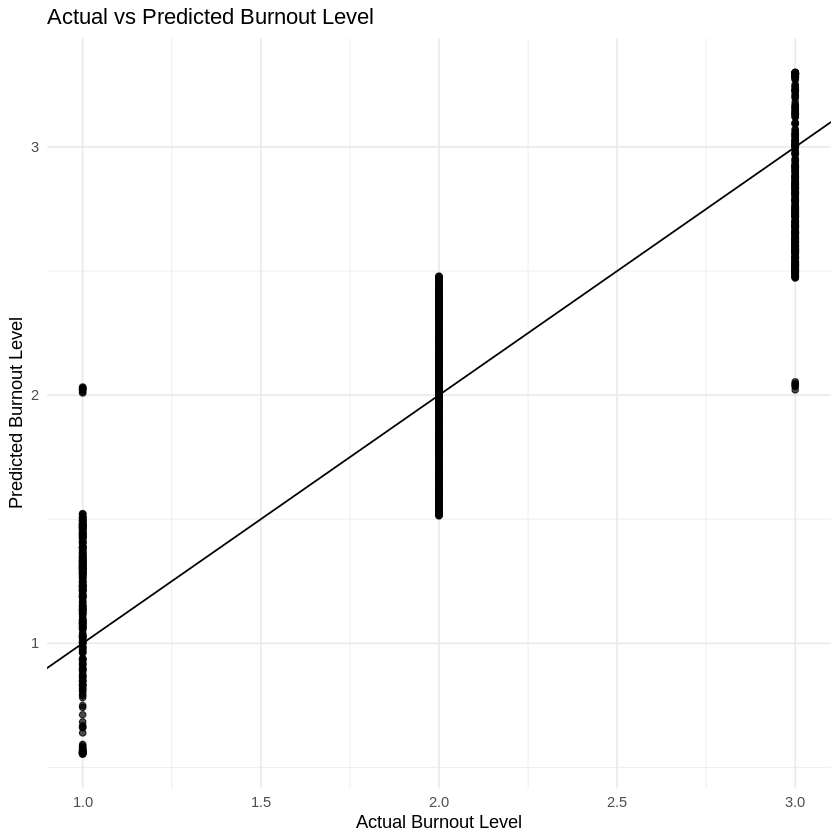

In [ ]:
plot_data <- data.frame(
  actual = actual,
  predicted = predictions
)

ggplot(plot_data, aes(x = actual, y = predicted)) +
  geom_point(alpha = 0.7, size = 1.5) +
  geom_abline(intercept = 0, slope = 1) +
  labs(
    title = "Actual vs Predicted Burnout Level",
    x = "Actual Burnout Level",
    y = "Predicted Burnout Level"
  ) +
  theme_minimal()

# Python vs R comparison:
* Python and R produced very similar regression results because both analyses used the same developer burnout dataset, target variable, and predictor variables. In Python, the model produced an R² of 0.8132, an adjusted R² of 0.8125, an RMSE of 0.3013, and a model accuracy of 81.32%. In R, the model produced a Training R² of 0.8203, an adjusted R² of 0.8201, a Test R² of 0.8076, an RMSE of 0.3026, and a model accuracy of 80.76%.

* The results are highly consistent across both languages. The R² values in both Python and R are around 0.81, indicating that approximately 81% of the variation in burnout_level is explained by the model. The RMSE values are also nearly identical (about 0.30), showing that both models have similar prediction error. The small differences in values are expected due to differences in how Python and R perform train-test splitting and internal numerical calculations.

* Both models used daily_work_hours, sleep_hours, stress_level, screen_time, and exercise_hours as predictors, and the results confirm that burnout is influenced by both work-related factors and lifestyle factors. Python was useful for the machine learning workflow using scikit-learn, while R was useful for statistical interpretation because lm() provides detailed outputs such as coefficients, p-values, R², and adjusted R².